## Section 9: Final Model Evaluation and Conclusion

### Model Evaluation

Having trained and tuned two classical models (Random Forest, XGBoost) and one Neural Network (MLP), we now perform a final comparative analysis.

This notebook will:
- Compare models using MAE, RMSE, and R² metrics.
- Analyze error distribution across different Challenge Rating tiers.
- Discuss the trade-offs between model complexity and predictive power.
- Provide a final recommendation for implementation.

In [56]:
import pandas as pd
import numpy as np
import joblib
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


X_test = pd.read_csv('../data/final_split/X_test_nn.csv')
y_test = pd.read_csv('../data/final_split/y_test_nn.csv').values.ravel()


rf_model = joblib.load('../models/classical_tuned/tuned_rf_model.pkl')
xgb_model = joblib.load('../models/classical_tuned/tuned_xgb_model.pkl')


class CRPredictor(nn.Module): # todo: maybe make a separate file for this?
    """
    Feedforward MLP for predicting D&D monster Challenge Rating.
    
    Args:
        input_dim:     Number of input features (27)
        hidden_layers: Tuple of neuron counts per hidden layer, e.g. (128, 64, 32)
        dropout:       Dropout rate applied after each hidden layer
    """
    
    def __init__(self, input_dim, hidden_layers=(128, 64, 32), dropout=0.3):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for neurons in hidden_layers:
            layers.extend([
                nn.Linear(prev_dim, neurons),
                nn.BatchNorm1d(neurons),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = neurons
        
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

model_nn = CRPredictor(
    input_dim=X_test.shape[1],
    hidden_layers=(128, 64, 32),  
    dropout=0.3  
)
model_nn.load_state_dict(torch.load('../models/nn_tuned/nn_tuned.pth'))
model_nn.eval()


rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

with torch.no_grad():
    nn_preds = model_nn(torch.tensor(X_test.values, dtype=torch.float32)).numpy().ravel()

results_df = pd.DataFrame({
    'Actual': y_test,
    'Random Forest': rf_preds,
    'XGBoost': xgb_preds,
    'Neural Network': nn_preds
})

In [ ]:
# Baseline vs Tuned comparison (baselines loaded from saved .pkl files)
baseline_rf  = joblib.load('../models/classical_baseline/baseline_rf_model.pkl')
baseline_xgb = joblib.load('../models/classical_baseline/baseline_xgb_model.pkl')

baseline_rf_preds  = baseline_rf.predict(X_test)
baseline_xgb_preds = baseline_xgb.predict(X_test)

tuning_comparison = pd.DataFrame({
    'RF (baseline)':   get_metrics(y_test, baseline_rf_preds),
    'RF (tuned)':      get_metrics(y_test, rf_preds),
    'XGB (baseline)':  get_metrics(y_test, baseline_xgb_preds),
    'XGB (tuned)':     get_metrics(y_test, xgb_preds),
}).T

print("Impact of Hyperparameter Tuning")
display(tuning_comparison.round(4))

# Print the improvement deltas explicitly
for label, base_p, tuned_p in [
    ("Random Forest", baseline_rf_preds, rf_preds),
    ("XGBoost",       baseline_xgb_preds, xgb_preds),
]:
    delta = mean_absolute_error(y_test, base_p) - mean_absolute_error(y_test, tuned_p)
    print(f"{label}: MAE improved by {delta:.4f} after tuning")

Impact of Hyperparameter Tuning


,MAE,RMSE,R2
RF (baseline),0.8902,1.3670,0.9503
RF (tuned),0.8819,1.3562,0.9511
XGB (baseline),0.9035,1.4105,0.9471
XGB (tuned),0.8531,1.3279,0.9531


Random Forest: MAE improved by 0.0083 after tuning
XGBoost: MAE improved by 0.0504 after tuning


In [58]:
# Metric Comparison Summary
def get_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

comparison_table = pd.DataFrame({
    'Random Forest': get_metrics(y_test, rf_preds),
    'XGBoost': get_metrics(y_test, xgb_preds),
    'Neural Network': get_metrics(y_test, nn_preds)
}).T

print("Global Model Performance Table")
display(comparison_table.round(4))

best_mae_model = comparison_table['MAE'].idxmin()
best_rmse_model = comparison_table['RMSE'].idxmin()
best_r2_model = comparison_table['R2'].idxmax()

print("Best Models by Metric")
print(f"Lowest MAE: {best_mae_model}")
print(f"Lowest RMSE: {best_rmse_model}")
print(f"Highest R²: {best_r2_model}")


Global Model Performance Table


,MAE,RMSE,R2
Random Forest,0.8819,1.3562,0.9511
XGBoost,0.8531,1.3279,0.9531
Neural Network,0.9351,1.4369,0.9451


Best Models by Metric
Lowest MAE: XGBoost
Lowest RMSE: XGBoost
Highest R²: XGBoost


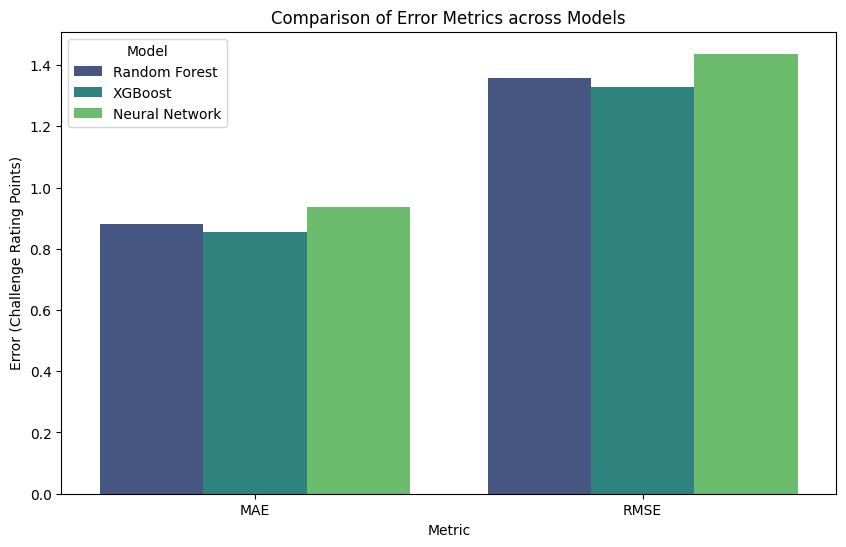

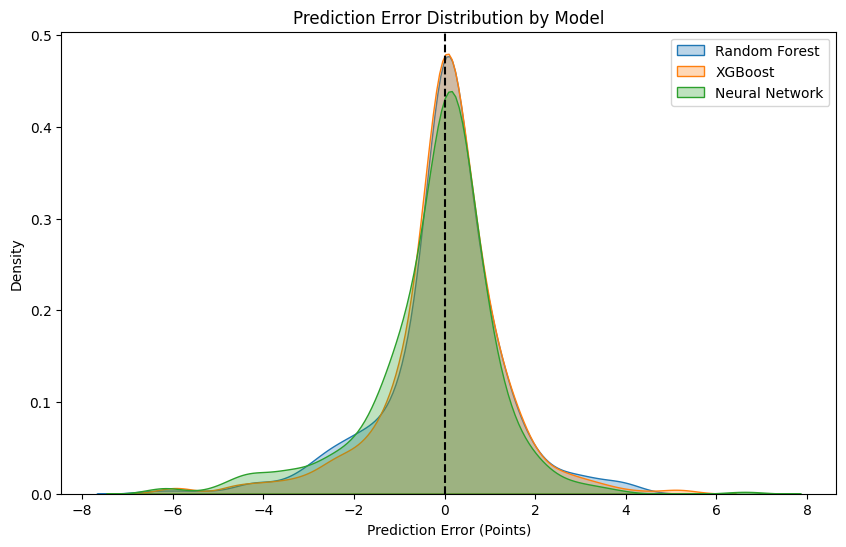

 Residual Statistics
Random Forest:
  Mean Error     = -0.0388
  Std Deviation  = 1.3571
  Max Error      = 4.2600
  Min Error      = -6.4943

XGBoost:
  Mean Error     = -0.0162
  Std Deviation  = 1.3292
  Max Error      = 5.2670
  Min Error      = -6.1289

Neural Network:
  Mean Error     = -0.2302
  Std Deviation  = 1.4198
  Max Error      = 6.6224
  Min Error      = -6.2318



In [59]:
# Grouped Bar Chart for MAE and RMSE 
metrics_melted = comparison_table.reset_index().melt(
    id_vars='index',
    value_vars=['MAE', 'RMSE']
)
metrics_melted.columns = ['Model', 'Metric', 'Value']

plt.figure(figsize=(10, 6))
sns.barplot(
    data=metrics_melted,
    x='Metric',
    y='Value',
    hue='Model',
    palette='viridis'
)
plt.title('Comparison of Error Metrics across Models')
plt.ylabel('Error (Challenge Rating Points)')
plt.show()

# Error Distribution Comparison
plt.figure(figsize=(10, 6))

for col in ['Random Forest', 'XGBoost', 'Neural Network']:
    sns.kdeplot(
        results_df[col] - results_df['Actual'],
        label=col,
        fill=True,
        alpha=0.3
    )

plt.axvline(0, color='black', linestyle='--')
plt.title('Prediction Error Distribution by Model')
plt.xlabel('Prediction Error (Points)')
plt.legend()
plt.show()

print(" Residual Statistics")
for col in ['Random Forest', 'XGBoost', 'Neural Network']:
    residuals = results_df[col] - results_df['Actual']
    
    print(f"{col}:")
    print(f"  Mean Error     = {residuals.mean():.4f}")
    print(f"  Std Deviation  = {residuals.std():.4f}")
    print(f"  Max Error      = {residuals.max():.4f}")
    print(f"  Min Error      = {residuals.min():.4f}\n")

MAE by Monster Tier


,Random Forest,XGBoost,Neural Network
Tier,,,
0-1 (Minions),0.259,0.282,0.294
1-5 (Low),0.651,0.605,0.663
5-10 (Mid),1.302,1.323,1.260
10-20 (High),1.642,1.584,1.659
20+ (Bosses),1.566,1.282,2.509


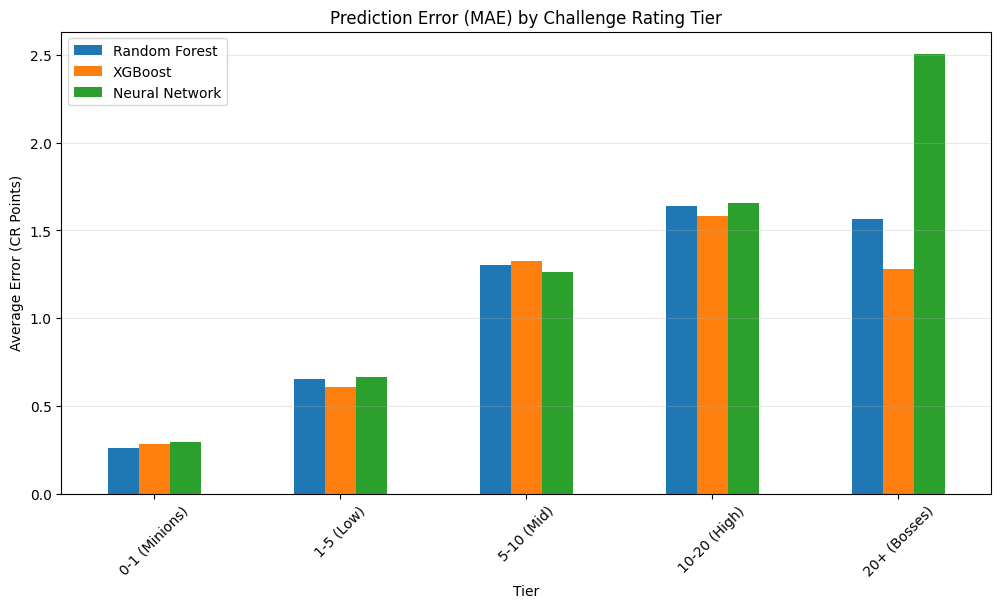

In [60]:

bins = [-np.inf, 1, 5, 10, 20, np.inf]
labels = ['0-1 (Minions)', '1-5 (Low)', '5-10 (Mid)', '10-20 (High)', '20+ (Bosses)']

results_df['Tier'] = pd.cut(results_df['Actual'], bins=bins, labels=labels)

tier_mae = pd.DataFrame()

for model in ['Random Forest', 'XGBoost', 'Neural Network']:
    tier_mae[model] = results_df.groupby('Tier', observed=False).apply(
        lambda x: mean_absolute_error(x['Actual'], x[model])
    )

print("MAE by Monster Tier")
display(tier_mae.round(3))

tier_mae.plot(kind='bar', figsize=(12, 6))
plt.title('Prediction Error (MAE) by Challenge Rating Tier')
plt.ylabel('Average Error (CR Points)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()


In [61]:
import pandas as pd

# Create an analysis dataframe joining errors with features
outlier_analysis = X_test.copy()
outlier_analysis['Actual'] = y_test
outlier_analysis['XGB_Pred'] = xgb_preds
outlier_analysis['NN_Pred'] = nn_preds
outlier_analysis['RF_Pred'] = rf_preds

outlier_analysis['RF_Error'] = abs(rf_preds - y_test)
outlier_analysis['XGB_Error'] = abs(xgb_preds - y_test)
outlier_analysis['NN_Error'] = abs(nn_preds - y_test)

for model_name, pred_col, error_col in [
    ("Random Forest", "RF_Pred", "RF_Error"),
    ("XGBoost", "XGB_Pred", "XGB_Error"),
    ("Neural Network", "NN_Pred", "NN_Error"),
]:
    top_errors = outlier_analysis.sort_values(by=error_col, ascending=False).head(10)
    print(f"=== Top 10 {model_name} Errors ===")
    display(top_errors[["Actual", pred_col, error_col,
                         "Is_Legendary", "Is_Spellcaster", "Log_Avg_HP", "AC_Z"]])
    print()


print("Correlation between Prediction Error and ALL features:")
feature_cols = [col for col in X_test.columns]  # all 27 features

corr_results = pd.DataFrame({
    'XGB_Error_Corr': [outlier_analysis['XGB_Error'].corr(outlier_analysis[f]) for f in feature_cols],
    'NN_Error_Corr':  [outlier_analysis['NN_Error'].corr(outlier_analysis[f]) for f in feature_cols],
    'RF_Error_Corr':  [outlier_analysis['RF_Error'].corr(outlier_analysis[f]) for f in feature_cols],
}, index=feature_cols)

corr_results['Avg_Corr'] = corr_results.mean(axis=1)
display(corr_results.sort_values('Avg_Corr', ascending=False).round(4))

=== Top 10 Random Forest Errors ===


,Actual,RF_Pred,RF_Error,Is_Legendary,Is_Spellcaster,Log_Avg_HP,AC_Z
463,17.0,10.505714,6.494286,0,0,5.141664,1.792507
450,16.0,10.080000,5.920000,0,0,5.323010,-0.568671
199,15.0,9.719967,5.280033,0,0,5.036953,0.105951
223,23.0,18.530000,4.470000,1,0,5.579730,1.455196
20,8.0,3.552002,4.447998,0,0,4.077537,0.105951
280,19.0,14.730000,4.270000,1,0,5.451038,0.780574
431,8.0,12.260000,4.260000,0,0,5.429346,0.780574
416,16.0,11.915000,4.085000,0,0,5.379897,1.117885
339,10.0,5.960000,4.040000,0,1,4.510860,1.117885
144,12.0,16.000000,4.000000,0,0,5.579730,0.780574



=== Top 10 XGBoost Errors ===


,Actual,XGB_Pred,XGB_Error,Is_Legendary,Is_Spellcaster,Log_Avg_HP,AC_Z
463,17.0,10.871132,6.128868,0,0,5.141664,1.792507
250,12.0,6.146272,5.853728,0,0,5.062595,-0.231360
183,10.0,4.154161,5.845839,0,0,5.187386,0.780574
431,8.0,13.267025,5.267025,0,0,5.429346,0.780574
176,8.0,13.020164,5.020164,1,1,4.709530,-0.231360
450,16.0,11.263042,4.736958,0,0,5.323010,-0.568671
199,15.0,10.460347,4.539653,0,0,5.036953,0.105951
416,16.0,11.489837,4.510163,0,0,5.379897,1.117885
133,16.0,11.622994,4.377006,0,0,5.252273,0.780574
206,12.0,16.234383,4.234383,1,1,5.036953,1.792507



=== Top 10 Neural Network Errors ===


,Actual,NN_Pred,NN_Error,Is_Legendary,Is_Spellcaster,Log_Avg_HP,AC_Z
176,8.0,14.622438,6.622438,1,1,4.709530,-0.231360
463,17.0,10.768220,6.231780,0,0,5.141664,1.792507
379,21.0,14.779881,6.220119,1,1,4.912655,0.780574
199,15.0,8.949064,6.050936,0,0,5.036953,0.105951
250,12.0,7.021413,4.978587,0,0,5.062595,-0.231360
152,25.0,20.061985,4.938015,0,1,6.070738,2.467130
425,15.0,10.450814,4.549186,0,0,5.278115,-0.905982
450,16.0,11.516191,4.483809,0,0,5.323010,-0.568671
132,26.0,21.533567,4.466433,0,0,6.285998,2.467130
20,8.0,3.643834,4.356166,0,0,4.077537,0.105951



Correlation between Prediction Error and ALL features:


,XGB_Error_Corr,NN_Error_Corr,RF_Error_Corr,Avg_Corr
Log_Avg_HP,0.4471,0.4661,0.4757,0.4630
Constitution_Z,0.3973,0.3892,0.4058,0.3974
Strength_Z,0.3447,0.3173,0.3732,0.3451
Size_Rank,0.3324,0.2776,0.3721,0.3274
AC_Z,0.2412,0.2957,0.2771,0.2713
Wisdom_Z,0.1933,0.3012,0.2150,0.2365
Action_Count_MM,0.1856,0.1967,0.2392,0.2072
Trait_Count_MM,0.1955,0.1946,0.1900,0.1934
Is_Legendary,0.1668,0.2220,0.1639,0.1842
Charisma_Z,0.1014,0.2412,0.1167,0.1531


Interestingly, legendary and spellcaster dont have a high correlation to the error.

The Error Analysis showed that prediction error is most strongly correlated with Log_Avg_HP (r ≈ 0.46 across all models), suggesting that monsters with disproportionately high HP relative to their CR are systematically harder to predict. Additional ability score features like Strength_Z and Constitution_Z may also contribute - see the full correlation table above.

TODO: longer explanation

Number of 'Hard-to-Predict' Monsters (Error > 4 across all models): 3


,Actual,XGB_Pred,RF_Pred,NN_Pred,Is_Legendary,Is_Spellcaster,Log_Avg_HP
199,15.0,10.460347,9.719967,8.949064,0,0,5.036953
450,16.0,11.263042,10.080000,11.516191,0,0,5.323010
463,17.0,10.871132,10.505714,10.768220,0,0,5.141664


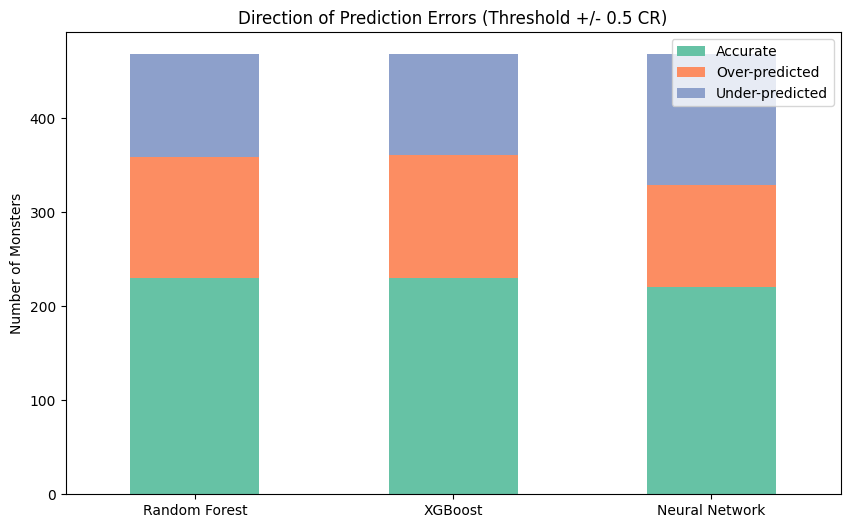

Prediction Direction Counts:


,Accurate,Over-predicted,Under-predicted
Random Forest,230,129,109
XGBoost,230,131,107
Neural Network,221,108,139



As percentages:


,Accurate,Over-predicted,Under-predicted
Random Forest,49.1,27.6,23.3
XGBoost,49.1,28.0,22.9
Neural Network,47.2,23.1,29.7


In [62]:
# common outliers across all models
outlier_analysis['RF_Error'] = abs(rf_preds - y_test)
threshold = 4.0  # monsters where error is > 4 CR points

common_outliers = outlier_analysis[
    (outlier_analysis['RF_Error'] > threshold) &
    (outlier_analysis['XGB_Error'] > threshold) &
    (outlier_analysis['NN_Error'] > threshold)
]

print(f"Number of 'Hard-to-Predict' Monsters (Error > 4 across all models): {len(common_outliers)}")
display(common_outliers[['Actual', 'XGB_Pred', 'RF_Pred', 'NN_Pred', 'Is_Legendary', 'Is_Spellcaster',
                         'Log_Avg_HP']].head(10))

# determine the 'Direction' of error (Under-prediction vs Over-prediction)
bias_df = pd.DataFrame()
for model_name in ['Random Forest', 'XGBoost', 'Neural Network']:
    errors = results_df[model_name] - results_df['Actual']
    bias_df[model_name] = [
        'Under-predicted' if x < -0.5 else 'Over-predicted' if x > 0.5 else 'Accurate'
        for x in errors
    ]

bias_summary = bias_df.apply(pd.Series.value_counts).T
bias_summary.plot(
    kind='bar', stacked=True, figsize=(10, 6),
    color=['#66c2a5', '#fc8d62', '#8da0cb']
)
plt.title('Direction of Prediction Errors (Threshold +/- 0.5 CR)')
plt.ylabel('Number of Monsters')
plt.xticks(rotation=0)
plt.show()
bias_df = pd.DataFrame()
for model_name in ['Random Forest', 'XGBoost', 'Neural Network']:
    errors = results_df[model_name] - results_df['Actual']
    bias_df[model_name] = [
        'Under-predicted' if x < -0.5 else 'Over-predicted' if x > 0.5 else 'Accurate'
        for x in errors
    ]

bias_summary = bias_df.apply(pd.Series.value_counts).T
print("Prediction Direction Counts:")
display(bias_summary)

print("\nAs percentages:")
display((bias_summary.div(bias_summary.sum(axis=1), axis=0) * 100).round(1))

The funnel shape confirms **heteroscedasticity** wherein prediction variance increases with CR. 
1. At CR 5 and below, models are highly reliable (residuals cluster near 0). 
2. At CR 15+, errors spread ±5 CR points, meaning the model may be off by an entire difficulty tier. 

    - This is consistent with the boss-tier MAE results and suggests that ensemble models learn the low-CR distribution well, but lack sufficient training signal for rare high-CR monsters.

Notably, residuals skew negative at high predicted values -- the models systematically **under-predict** powerful monsters. A DM using this tool for a CR 20+ boss should expect the tool to suggest a lower CR than the actual one.

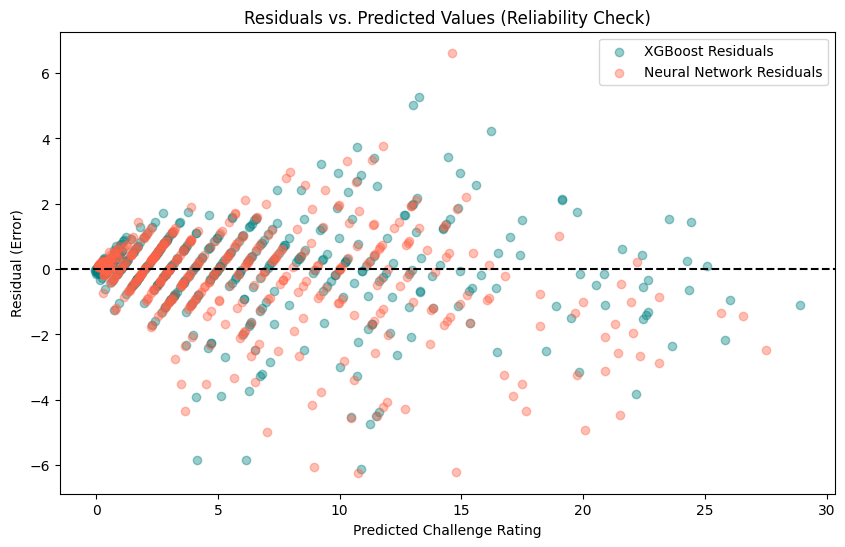

In [63]:
plt.figure(figsize=(10, 6))
plt.scatter(xgb_preds, xgb_preds - y_test, alpha=0.4, color='teal', label='XGBoost Residuals')
plt.scatter(nn_preds, nn_preds - y_test, alpha=0.4, color='tomato', label='Neural Network Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals vs. Predicted Values (Reliability Check)')
plt.xlabel('Predicted Challenge Rating')
plt.ylabel('Residual (Error)')
plt.legend()
plt.show()

In [64]:
# checking within n cr accuracy again to be self contained
def within_n_cr(y_true, y_pred, n=1):
    return np.mean(np.abs(y_true - y_pred) <= n)

print("Within 1 CR Accuracy:")
for name, preds in [("Random Forest", rf_preds), ("XGBoost", xgb_preds), ("Neural Network", nn_preds)]:
    print(f"  {name}: {within_n_cr(y_test, preds, n=1):.1%}")

print("\nWithin 2 CR Accuracy:")
for name, preds in [("Random Forest", rf_preds), ("XGBoost", xgb_preds), ("Neural Network", nn_preds)]:
    print(f"  {name}: {within_n_cr(y_test, preds, n=2):.1%}")

Within 1 CR Accuracy:
  Random Forest: 68.8%
  XGBoost: 71.4%
  Neural Network: 69.0%

Within 2 CR Accuracy:
  Random Forest: 87.6%
  XGBoost: 89.1%
  Neural Network: 87.8%


### Discussion of Findings

#### The Superiority of Tree Ensembles
The XGBoost model (R²: 0.953) outperformed the Neural Network across almost all tiers. 
- This is likely due to the Ordinal and Tabular Nature of the dataset. 
- As seen from our EDA and feature importance charts, D&D Challenge Ratings seem to follow a "step-function" logic where certain stat thresholds (like HP ranges) trigger specific CR increases. 
- Decision trees are naturally suited to capture these discrete boundaries better than the continuous activation functions of a Neural Network.

#### Performance of the Neural Network:
The Neural Network (MLP) performed similarly, but got exponentially worse at higher CRs.
- While the MLP used Huber Loss to handle outliers, it likely struggled compared to tree-ensembles due to the relatively small dataset size (~2,000 samples). Neural networks typically require more data to outperform tuned gradient-boosted trees on structured data.

#### The Data Scarcity Problem
All models exhibit a sharp drop at CR 15+. 
- As shown in Section 7's feature importance analysis, Log_Avg_HP and Is_Legendary are the top predictors across both tree models, which aligns with the error correlation results above.
- 


### Final Model Recommendation
We recommend the **XGBoost Model** for implementation in a D&D CR predictor.
   - Accuracy: Lowest overall MAE (0.85) and RMSE.
   - Stability: Highest "Within 1 CR" accuracy (71.3%).
   - Efficiency: The model is lightweight, requires no GPU for inference, and significantly outperforms the Neural
     Network in boss-tier stability.

### Limitations and Future Work
- Current models do not account for specific "Damage Resistances" or "Immunities," which significantly impact CR.
- Future iterations could benefit from synthetic data for high-CR monsters to balance the tiers.

### References and AI Disclosure
- Dataset sourced from https://5e.tools/bestiary.html.
- **AI Tool Use:** 
  - Used AI to help me with the regex code during extraction
  - Used AI to help me with the sns in EDA